##**1. Tree Kanker Tiroid Menggunakan 4 Fitur**

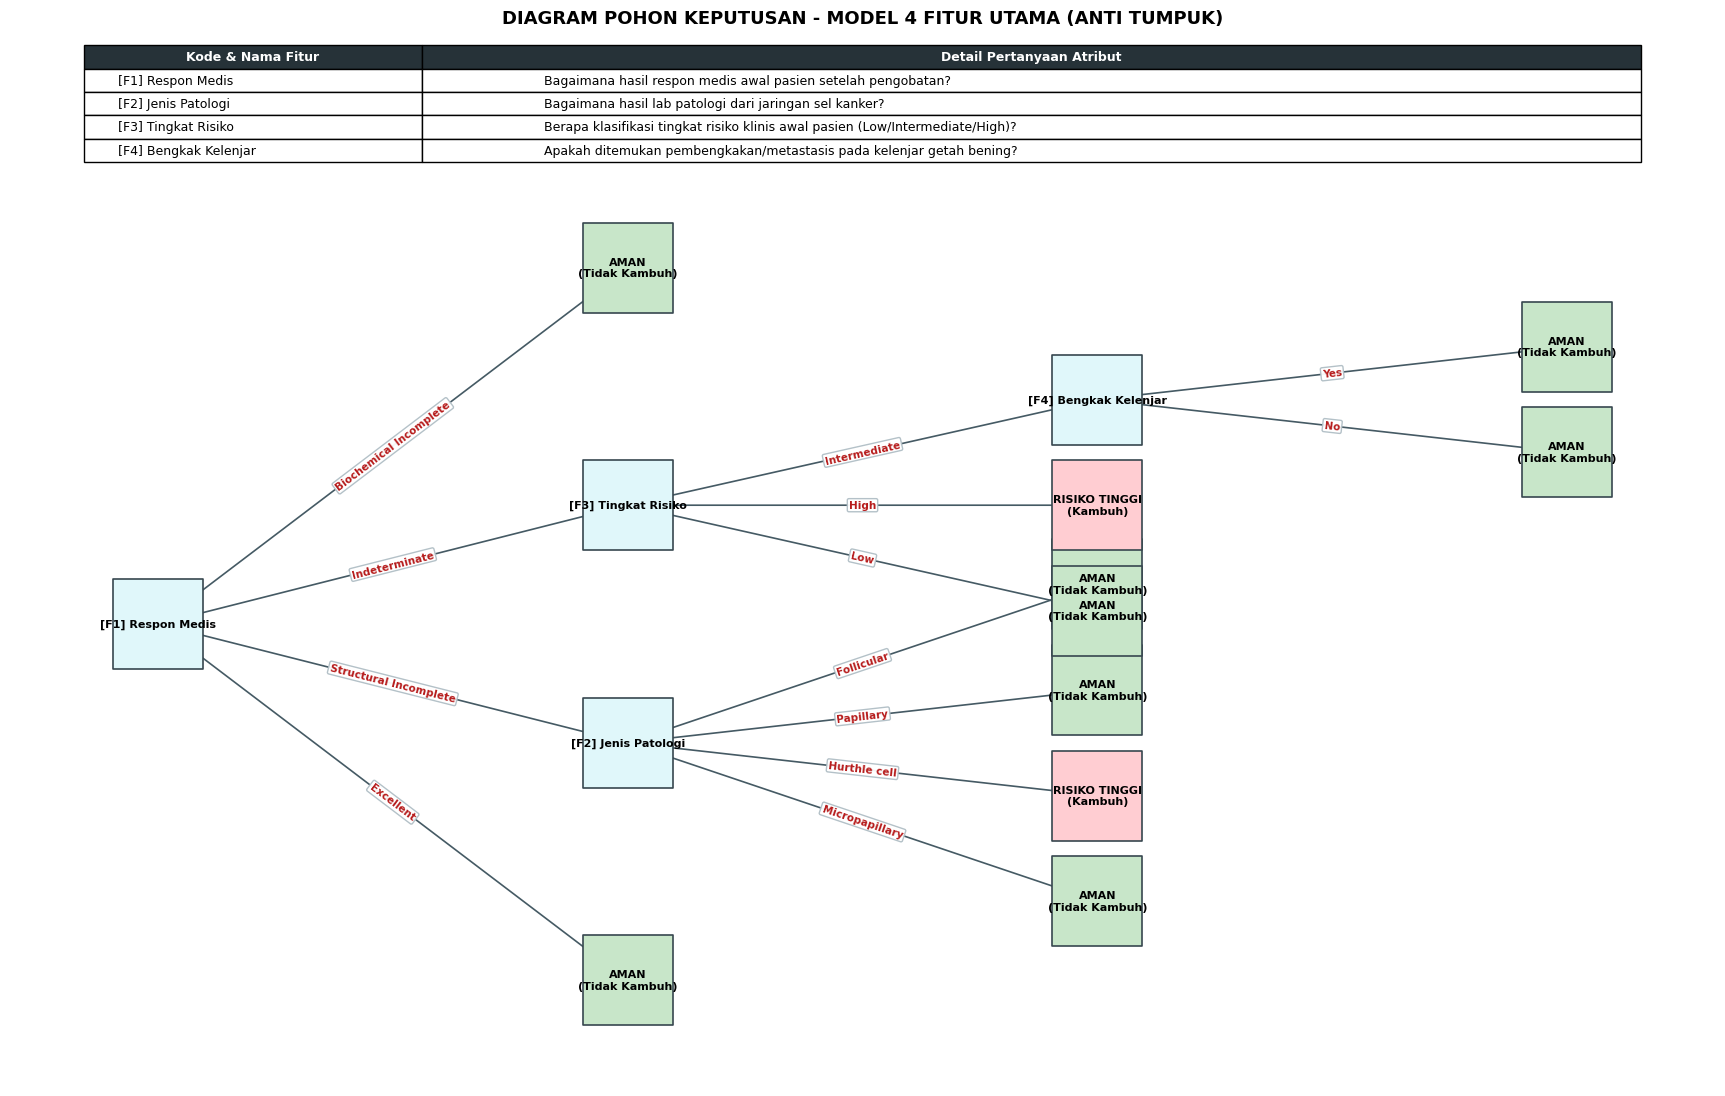

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Membuat node dari treenya
class Node:
    def __init__(self, konten_atau_hasil, nama_atribut=None):
        # Konten untuk menyimpan Pertanyaan atau Hasil akhir tree
        self.konten = konten_atau_hasil.strip()
        # Nama Atribut untuk menyimpan Nama Kolom dari tabel/dataset pasien
        self.nama_atribut = nama_atribut
        # Cabang untuk menyimpan alur/rute yang dilalui mulai dari Pertanyaan sampai hasil Akhir
        self.cabang = {}

    # Fungsi Tambah Cabang untuk memasukkan rute yang dilalui ke dalam variabel Cabang
    def tambah_cabang(self, pilihan_jawaban, node_anak):
        # Menambahkan Node Anak dengan jawabannya
        self.cabang[pilihan_jawaban] = node_anak

# Fungsi Buat Pohon Tiroid 4 Fitur untuk membuat Pohon Tiroid dengan 4 Fitur Utama
def buat_pohon_tiroid_4_fitur():
    # Buat Root/Akar dari Pohon/Tree dengan pertanyaan 1: Respon Medis
    root = Node("[F1] Respon Medis", nama_atribut="Response")
    # Pilihan jawaban Excellent langsung mengarah ke hasil AMAN
    root.tambah_cabang("Excellent", Node("AMAN\n(Tidak Kambuh)"))

    # Bikin Cabang untuk patologi (Structural Incomplete)
    node_patologi = Node("[F2] Jenis Patologi", nama_atribut="Pathology")
    # Masukkan pilihan jawaban Micropapillary ke hasil AMAN
    node_patologi.tambah_cabang("Micropapillary", Node("AMAN\n(Tidak Kambuh)"))
    # Masukkan pilihan jawaban Hurthle cell ke hasil RISIKO TINGGI
    node_patologi.tambah_cabang("Hurthle cell", Node("RISIKO TINGGI\n(Kambuh)"))
    # Masukkan pilihan jawaban Papillary ke hasil AMAN
    node_patologi.tambah_cabang("Papillary", Node("AMAN\n(Tidak Kambuh)"))
    # Masukkan pilihan jawaban Follicular ke hasil AMAN
    node_patologi.tambah_cabang("Follicular", Node("AMAN\n(Tidak Kambuh)"))
    # Gabungkan cabang patologi ke root utama kalau responnya Structural Incomplete
    root.tambah_cabang("Structural Incomplete", node_patologi)

    # Bikin Cabang untuk tingkat risiko (Indeterminate)
    node_risiko = Node("[F3] Tingkat Risiko", nama_atribut="Risk")
    # Kalau risiko Low, langsung arahkan ke hasil AMAN
    node_risiko.tambah_cabang("Low", Node("AMAN\n(Tidak Kambuh)"))
    # Kalau risiko High, langsung arahkan ke hasil RISIKO TINGGI
    node_risiko.tambah_cabang("High", Node("RISIKO TINGGI\n(Kambuh)"))

    # Bikin Cabang untuk kelenjar getah bening (Intermediate)
    node_kelenjar = Node("[F4] Bengkak Kelenjar", nama_atribut="Adenopathy")
    # Kalau tidak bengkak (No), arahkan ke AMAN
    node_kelenjar.tambah_cabang("No", Node("AMAN\n(Tidak Kambuh)"))
    # Kalau bengkak (Yes), arahkan ke AMAN (sesuai dataset 4 fitur)
    node_kelenjar.tambah_cabang("Yes", Node("AMAN\n(Tidak Kambuh)"))

    # Gabungkan cabang kelenjar ke tingkat risiko Intermediate
    node_risiko.tambah_cabang("Intermediate", node_kelenjar)
    # Gabungkan cabang tingkat risiko ke root utama kalau responnya Indeterminate
    root.tambah_cabang("Indeterminate", node_risiko)

    # Kalau responnya Biochemical Incomplete, langsung arahkan ke AMAN
    root.tambah_cabang("Biochemical Incomplete", Node("AMAN\n(Tidak Kambuh)"))

    # Kembalikan struktur pohon 4 fitur yang sudah jadi
    return root

def tampilkan_grafik_4_fitur(root_node):
    # Persiapan buat ngegambar tree pakai library NetworkX
    G = nx.DiGraph()
    # Bikin wadah dictionary untuk nyimpen koordinat posisi tiap kotak
    pos = {}

    # Fungsi rekursif buat ngitung posisi tiap kotak biar nggak tumpuk (Anti-Tumpuk)
    def hitung_posisi_dan_daftarkan(node, x=0, y=0, level=0, parent_id=None, label_panah=""):
        # Kalau nodenya kosong, hentikan proses untuk cabang ini
        if node is None:
            return

        # Bikin ID unik buat tiap node biar grafiknya rapi dan nggak ketuker
        node_id = node.konten if not parent_id else f"{node.konten} ({label_panah}) [{parent_id[-5:]}]"
        # Daftarin node beserta label teksnya ke dalam graf
        G.add_node(node_id, label=node.konten)
        # Simpan posisi koordinat X dan Y untuk node tersebut
        pos[node_id] = (x, y)

        # Nyambungin garis dari parent ke anak (node saat ini)
        if parent_id:
            G.add_edge(parent_id, node_id, title=label_panah)

        # Hitung jumlah cabang yang dimiliki node ini
        num_cabang = len(node.cabang)
        # Ulangi untuk setiap pilihan jawaban dan node anaknya
        for idx, (pilihan, anak) in enumerate(node.cabang.items()):
            # Ngatur jarak vertikal antar kotak supaya grafiknya presisi
            if level == 0:
                step_y = 1.8
            else:
                step_y = 0.8  # Jarak dipersempit biar tiap level nggak terlalu makan tempat

            # Geser posisi Y secara otomatis biar seimbang (nggak numpuk)
            offset_y = (idx - (num_cabang - 1) / 2) * step_y
            # Panggil fungsinya lagi untuk nentuin posisi anak-anaknya di level berikutnya
            hitung_posisi_dan_daftarkan(anak, x + 1, y + offset_y, level + 1, node_id, pilihan)

        # Mulai proses kalkulasi hitung posisi dari akar (root) dengan koordinat 0,0
    hitung_posisi_dan_daftarkan(root_node, x=0, y=0, level=0)

    # Atur ukuran kanvas buat gambarnya
    plt.figure(figsize=(22, 12))

    # Kasih warna kotak: Hijau kalau AMAN, Merah kalau RISIKO, Biru untuk pertanyaan biasa
    node_colors = ['#c8e6c9' if "AMAN" in n else '#ffcdd2' if "RISIKO" in n else '#e0f7fa' for n in G.nodes()]
    # Ambil label yang udah disimpen tadi dari atribut node
    labels = nx.get_node_attributes(G, 'label')

    # Gambar node bentuk kotak (square) beserta warnanya
    nx.draw_networkx_nodes(G, pos, node_size=4200, node_color=node_colors, node_shape='s', edgecolors='#37474f', linewidths=1.2)
    # Tulis teks/label di dalam kotaknya
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    # Gambar garis panah penghubung antar kotak
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=16, edge_color='#455a64', width=1.2)

    # Ambil teks pilihan jawaban untuk ditaruh di atas garis panah
    edge_labels = nx.get_edge_attributes(G, 'title')
    # Gambar teks pilihan jawaban tersebut dengan backgroud putih agar terbaca
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7.5, font_color='#b71c1c', font_weight='bold', bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="#b0bec5", alpha=0.95))

    # Bikin tabel legenda biar pembaca tahu arti dari tiap fitur yang dipakai
    data_legenda = [
        ["[F1] Respon Medis", "Bagaimana hasil respon medis awal pasien setelah pengobatan?"],
        ["[F2] Jenis Patologi", "Bagaimana hasil lab patologi dari jaringan sel kanker?"],
        ["[F3] Tingkat Risiko", "Berapa klasifikasi tingkat risiko klinis awal pasien (Low/Intermediate/High)?"],
        ["[F4] Bengkak Kelenjar", "Apakah ditemukan pembengkakan/metastasis pada kelenjar getah bening?"]
    ]
    # Bikin objek tabelnya dan atur posisinya nempel di atas (top)
    tabel_legenda = plt.table(cellText=data_legenda, colLabels=["Kode & Nama Fitur", "Detail Pertanyaan Atribut"], colWidths=[0.18, 0.65], loc="top", cellLoc="left")
    # Matikan auto font size biar bisa diatur manual
    tabel_legenda.auto_set_font_size(False)
    # Atur ukuran font tabel
    tabel_legenda.set_fontsize(9)
    # Atur skala tinggi baris tabel agar tidak terlalu gepeng
    tabel_legenda.scale(1.1, 1.4)

    # Styling header tabel legenda biar kelihatan lebih profesional dan menonjol
    for (row, col), cell in tabel_legenda.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#263238')

    # Batasin area Y gambar biar porsinya pas dan tabel tidak menutupi grafik
    ax = plt.gca()
    ax.set_ylim(-3.5, 3.5)

    # Kasih judul utama diagram
    plt.title("DIAGRAM POHON KEPUTUSAN - MODEL 4 FITUR UTAMA (ANTI TUMPUK)", fontsize=13, fontweight='bold', pad=100)
    # Hilangin garis sumbu X dan Y biar bersih
    plt.axis('off')
    # Tampilin grafiknya ke layar
    plt.show()

pohon_4_fitur = buat_pohon_tiroid_4_fitur()
tampilkan_grafik_4_fitur(pohon_4_fitur)

In [ ]:
# D. REKURSIF TRAVERSAL & EVALUASI 5 DATA PASIEN CSV
def telusuri_alur_4_fitur(node, data_pasien):
    # Cek apakah sudah sampai di Daun (Hasil Akhir) yang nggak punya cabang lagi
    if not node.cabang:
        # Bersihkan spasi/enter liar lalu cetak kesimpulannya
        hasil_akhir = node.konten.replace('\n', ' ')
        print(f" -> [KESIMPULAN AKHIR: {hasil_akhir}]")
        # Langsung keluar dari fungsi (Berhenti)
        return

    # Ambil nama atribut (nama kolom) dari node saat ini
    atribut = node.nama_atribut
    # Cari jawaban dari data pasien di CSV berdasarkan atribut kolom tersebut
    jawaban = str(data_pasien[atribut]).strip()

    # Cetak nama pertanyaan (node) dan jawaban pasiennya
    print(f" -> [{node.konten}]({jawaban})", end="")

    # Kalau jawaban pasien ada di dalam daftar cabang
    if jawaban in node.cabang:
        # Panggil lagi fungsinya (rekursif) untuk pindah ke node anak yang dituju
        telusuri_alur_4_fitur(node.cabang[jawaban], data_pasien)
    else:
        # Kalau jawabannya nggak ada di pohon, cetak info jalur terhenti
        print(" -> [Jalur Terhenti: Kategori data tidak terdaftar di pohon]")

try:
    # 1. Panggil Pandas untuk membaca file CSV dataset
    df = pd.read_csv('Thyroid_Diff.csv')

    # 2. STRATEGI UTAMA: Menggabungkan 5 data pasien teratas dan 5 data pasien terbawah
    # .head(5) mengambil 5 baris pertama, .tail(5) mengambil 5 baris terakhir
    df_simulasi_4f = pd.concat([df.head(5), df.tail(5)])

    print("SIMULASI PENELUSURAN ALUR STRUKTUR DATA POHON PADA DATA PASIEN (5 AWAL & 5 AKHIR) - MODEL 4 FITUR")
    # Looping: Jalankan satu per satu menggunakan iterrows agar indeks asli tabel tetap terbac
    for indeks, baris in df_simulasi_4f.iterrows():
        # Print pembatas baris dengan menampilkan nomor indeks asli di dalam dataset CSV
        print(f"\n[PASIEN BARIS INDEX: #{indeks}]")
        # Print info rekam medis/klinis asli pasien dari kolom database
        print(f"Profil Klinis -> Response: {baris['Response']} | Pathology: {baris['Pathology']} | Risk: {baris['Risk']} | Adenopathy: {baris['Adenopathy']}")
        print("Jalur Pohon 4 Fitur:", end="")

        # Masukkan baris data pasien ke mesin penelusur rekursif alur 4 fitur
        telusuri_alur_4_fitur(pohon_4_fitur, baris)

except FileNotFoundError:
    # Memberikan pesan peringatan apabila lokasi file CSV tidak berada di folder running
    print("Gagal: Berkas 'Thyroid_Diff.csv' tidak ditemukan di direktori lokal.")

SIMULASI PENELUSURAN ALUR STRUKTUR DATA POHON PADA DATA PASIEN (5 AWAL & 5 AKHIR) - MODEL 4 FITUR

[PASIEN BARIS INDEX: #0]
Profil Klinis -> Response: Indeterminate | Pathology: Micropapillary | Risk: Low | Adenopathy: No
Jalur Pohon 4 Fitur: -> [[F1] Respon Medis](Indeterminate) -> [[F3] Tingkat Risiko](Low) -> [KESIMPULAN AKHIR: AMAN (Tidak Kambuh)]

[PASIEN BARIS INDEX: #1]
Profil Klinis -> Response: Excellent | Pathology: Micropapillary | Risk: Low | Adenopathy: No
Jalur Pohon 4 Fitur: -> [[F1] Respon Medis](Excellent) -> [KESIMPULAN AKHIR: AMAN (Tidak Kambuh)]

[PASIEN BARIS INDEX: #2]
Profil Klinis -> Response: Excellent | Pathology: Micropapillary | Risk: Low | Adenopathy: No
Jalur Pohon 4 Fitur: -> [[F1] Respon Medis](Excellent) -> [KESIMPULAN AKHIR: AMAN (Tidak Kambuh)]

[PASIEN BARIS INDEX: #3]
Profil Klinis -> Response: Excellent | Pathology: Micropapillary | Risk: Low | Adenopathy: No
Jalur Pohon 4 Fitur: -> [[F1] Respon Medis](Excellent) -> [KESIMPULAN AKHIR: AMAN (Tidak K

##**2. Tree Kanker Tiroid Menggunakan 6 Fitur**

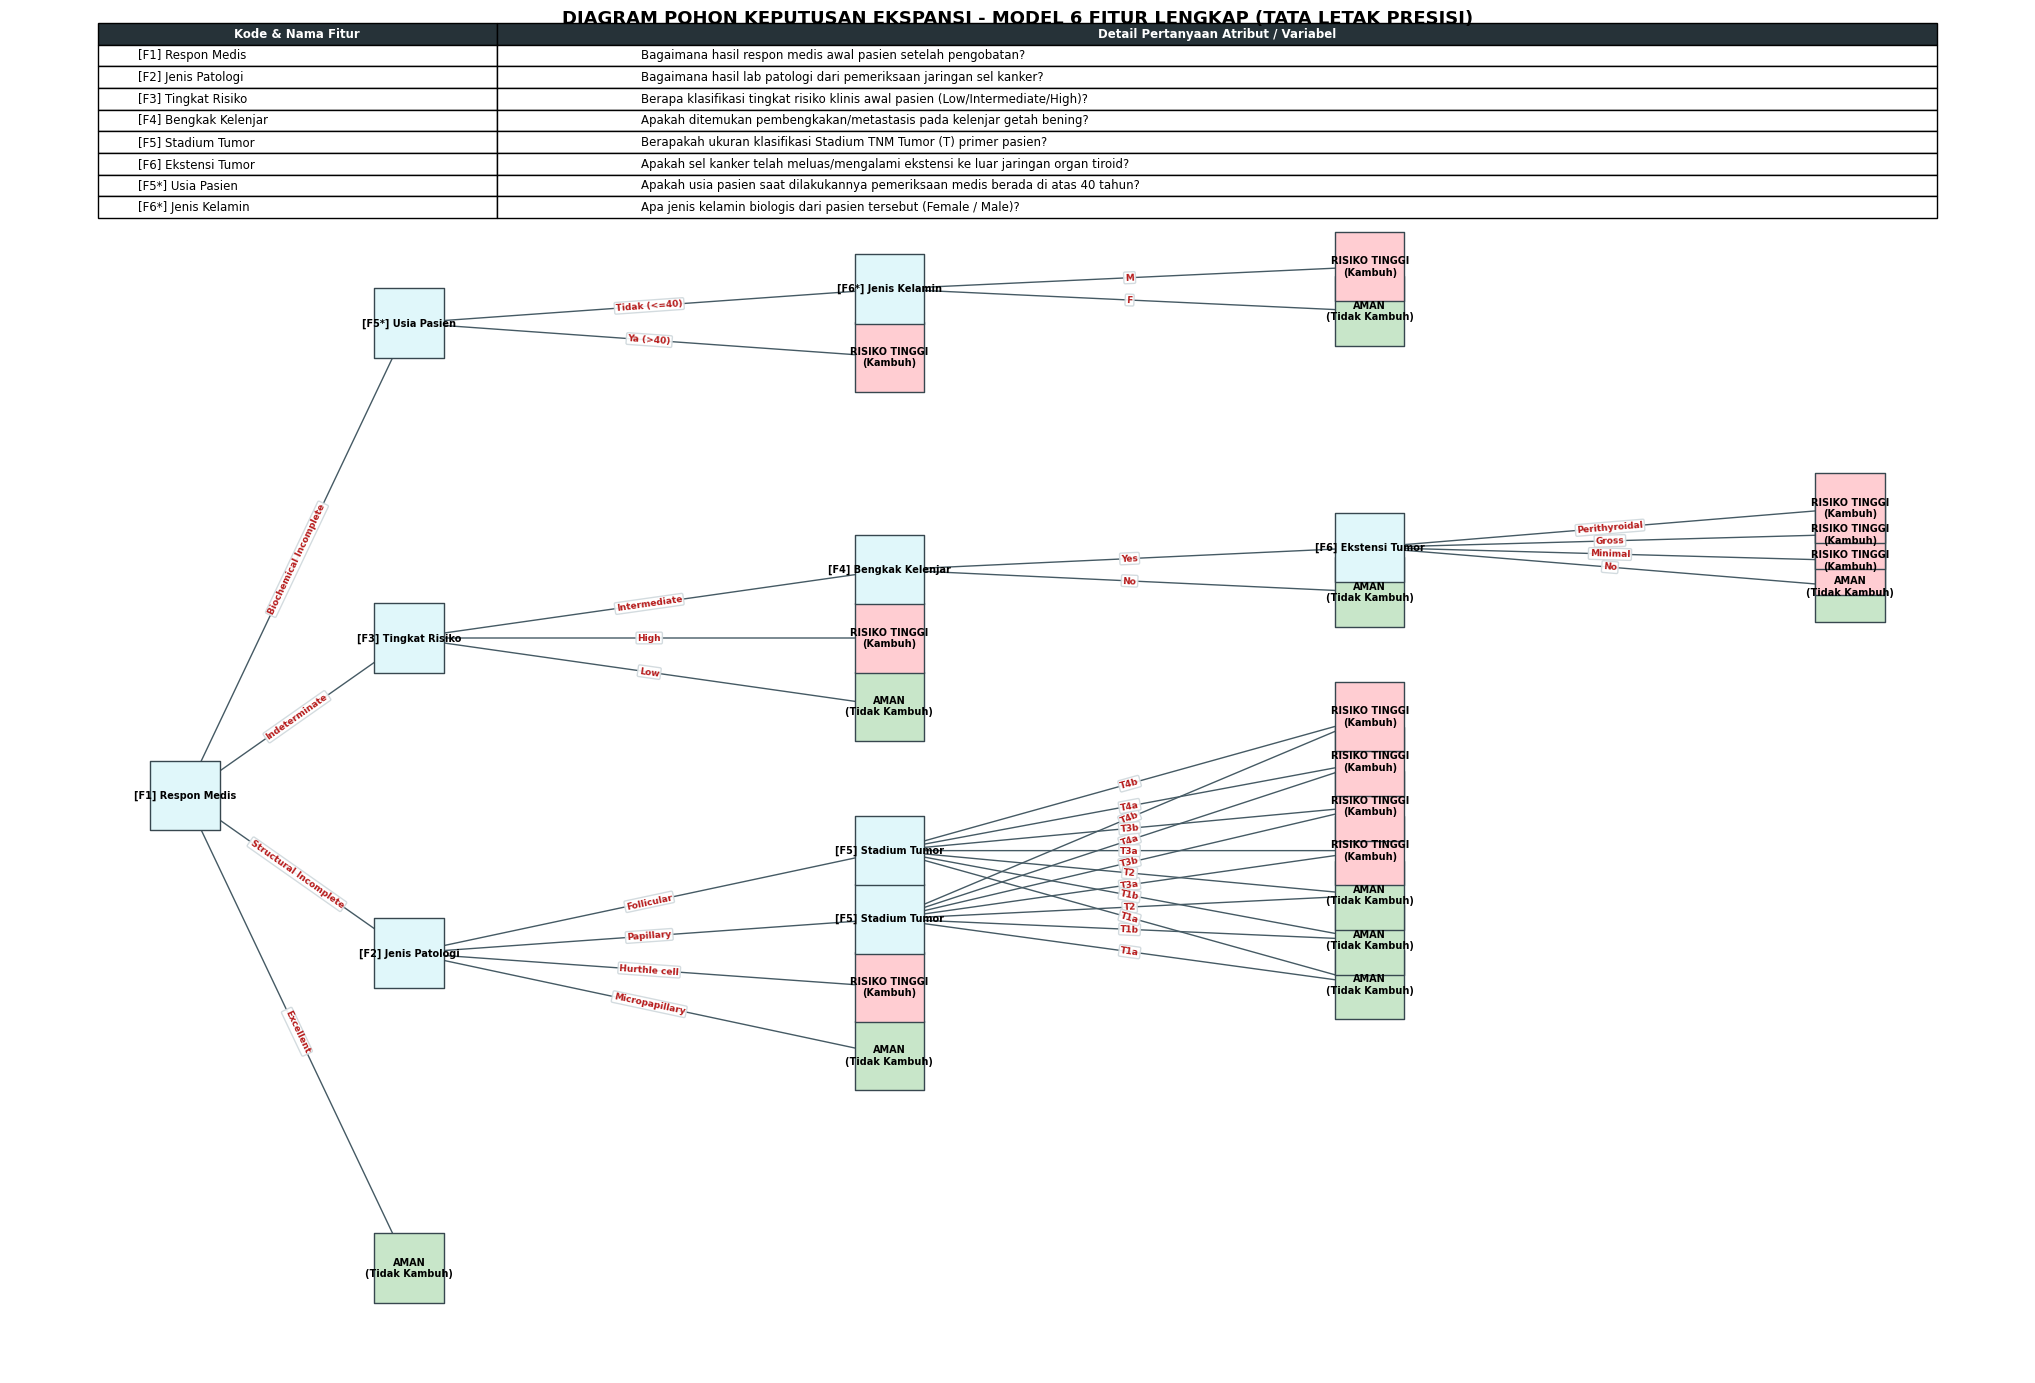

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

class Node:
    def __init__(self, konten_atau_hasil, nama_atribut=None):
        self.konten = konten_atau_hasil.strip()
        self.nama_atribut = nama_atribut
        self.cabang = {}

    def tambah_cabang(self, pilihan_jawaban, node_anak):
        self.cabang[pilihan_jawaban] = node_anak

def buat_pohon_tiroid_6_fitur_terpisah():
    # Akar utama 6 fitur dengan pertanyaan 1
    root = Node("[F1] Respon Medis", nama_atribut="Response")
    # Jawaban Excellent langsung mengarah ke hasil AMAN
    root.tambah_cabang("Excellent", Node("AMAN\n(Tidak Kambuh)"))

    # Bikin Cabang patologi untuk ekspansi
    node_patologi = Node("[F2] Jenis Patologi", nama_atribut="Pathology")
    # Jawaban Micropapillary mengarah ke AMAN
    node_patologi.tambah_cabang("Micropapillary", Node("AMAN\n(Tidak Kambuh)"))
    # Jawaban Hurthle cell mengarah ke RISIKO TINGGI
    node_patologi.tambah_cabang("Hurthle cell", Node("RISIKO TINGGI\n(Kambuh)"))

    # Bikin sub-ranting stadium tumor (F5) khusus untuk Papillary
    node_tumor_papi = Node("[F5] Stadium Tumor", nama_atribut="T")
    # Loop biar cepet: T1a, T1b, T2 arahkan ke AMAN
    for t in ["T1a", "T1b", "T2"]:
        node_tumor_papi.tambah_cabang(t, Node("AMAN\n(Tidak Kambuh)"))
    # Loop biar cepet: T3a, T3b, T4a, T4b arahkan ke RISIKO TINGGI
    for t in ["T3a", "T3b", "T4a", "T4b"]:
        node_tumor_papi.tambah_cabang(t, Node("RISIKO TINGGI\n(Kambuh)"))
    # Sambungkan sub-ranting tumor ini ke cabang Papillary
    node_patologi.tambah_cabang("Papillary", node_tumor_papi)

    # Bikin sub-ranting stadium tumor (F5) khusus untuk Follicular
    node_tumor_foll = Node("[F5] Stadium Tumor", nama_atribut="T")
    # Loop biar cepet: T1a, T1b, T2 arahkan ke AMAN
    for t in ["T1a", "T1b", "T2"]:
        node_tumor_foll.tambah_cabang(t, Node("AMAN\n(Tidak Kambuh)"))
    # Loop biar cepet: T3a, T3b, T4a, T4b arahkan ke RISIKO TINGGI
    for t in ["T3a", "T3b", "T4a", "T4b"]:
        node_tumor_foll.tambah_cabang(t, Node("RISIKO TINGGI\n(Kambuh)"))
    # Sambungkan sub-ranting tumor ini ke cabang Follicular
    node_patologi.tambah_cabang("Follicular", node_tumor_foll)

    # Gabungkan keseluruhan node patologi ke root utama (Structural Incomplete)
    root.tambah_cabang("Structural Incomplete", node_patologi)

    # Bikin Cabang untuk tingkat risiko (F3)
    node_risiko = Node("[F3] Tingkat Risiko", nama_atribut="Risk")
    # Kalau Low, arahkan ke AMAN
    node_risiko.tambah_cabang("Low", Node("AMAN\n(Tidak Kambuh)"))
    # Kalau High, arahkan ke RISIKO TINGGI
    node_risiko.tambah_cabang("High", Node("RISIKO TINGGI\n(Kambuh)"))

    # Bikin Cabang untuk Bengkak Kelenjar (F4)
    node_kelenjar = Node("[F4] Bengkak Kelenjar", nama_atribut="Adenopathy")
    # Kalau No, arahkan ke AMAN
    node_kelenjar.tambah_cabang("No", Node("AMAN\n(Tidak Kambuh)"))

    # Bikin sub-ranting Ekstensi Tumor (F6)
    node_ekstensi = Node("[F6] Ekstensi Tumor", nama_atribut="Extension")
    # Kalau No, arahkan ke AMAN
    node_ekstensi.tambah_cabang("No", Node("AMAN\n(Tidak Kambuh)"))
    # Kalau Minimal, Gross, Perithyroidal, arahkan ke RISIKO TINGGI
    for ext in ["Minimal", "Gross", "Perithyroidal"]:
        node_ekstensi.tambah_cabang(ext, Node("RISIKO TINGGI\n(Kambuh)"))

    # Sambungkan ekstensi ke kelenjar kalau jawabannya Yes
    node_kelenjar.tambah_cabang("Yes", node_ekstensi)
    # Sambungkan kelenjar ke risiko kalau jawabannya Intermediate
    node_risiko.tambah_cabang("Intermediate", node_kelenjar)

    # Gabungkan keseluruhan node risiko ke root utama (Indeterminate)
    root.tambah_cabang("Indeterminate", node_risiko)

    # Ranting khusus tambahan untuk Usia Pasien
    node_umur = Node("[F5*] Usia Pasien", nama_atribut="Age")
    # Ranting khusus tambahan untuk Jenis Kelamin
    node_gender = Node("[F6*] Jenis Kelamin", nama_atribut="Gender")
    # Kalau F, arahkan ke AMAN
    node_gender.tambah_cabang("F", Node("AMAN\n(Tidak Kambuh)"))
    # Kalau M, arahkan ke RISIKO TINGGI
    node_gender.tambah_cabang("M", Node("RISIKO TINGGI\n(Kambuh)"))

    # Kalau usianya Ya (>40) arahkan ke RISIKO TINGGI
    node_umur.tambah_cabang("Ya (>40)", Node("RISIKO TINGGI\n(Kambuh)"))
    # Kalau usianya Tidak (<=40) arahkan ke node_gender
    node_umur.tambah_cabang("Tidak (<=40)", node_gender)

    # Sambungkan node umur ke root utama (Biochemical Incomplete)
    root.tambah_cabang("Biochemical Incomplete", node_umur)

    # Kembalikan pohon 6 fitur utuhnya
    return root

def tampilkan_grafik_6_fitur_terpisah(root_node):
    # Persiapan ngegambar tree pakai NetworkX
    G = nx.DiGraph()
    # Bikin wadah untuk nyimpen koordinat posisi kotak
    pos = {}

    # Fungsi rekursif untuk ngitung posisi secara otomatis biar lega
    def hitung_posisi_otomatis(node, x=0, y=0, level=0, parent_id=None, label_panah=""):
        # Kalau nodenya kosong, berhenti
        if node is None:
            return

        # Bikin ID unik untuk setiap node
        node_id = node.konten if not parent_id else f"{node.konten} ({label_panah}) [{parent_id[-5:]}]"
        # Daftarin node ke dalam graf
        G.add_node(node_id, label=node.konten)

        # Jarak mendatar (X) diatur: Level awal dirapatkan (0.7), level dalamnya dilebarkan (1.5)
        dist_x = 0.7 if level == 0 else 1.5
        # Simpan posisi X dan Y
        pos[node_id] = (x, y)

        # Nyambungin garis panah dari parent ke anak
        if parent_id:
            G.add_edge(parent_id, node_id, title=label_panah)

        # Hitung jumlah cabang yang dipunya node ini
        num_cabang = len(node.cabang)
        # Ulangi untuk setiap cabang jawabannya
        for idx, (pilihan, anak) in enumerate(node.cabang.items()):
            # Atur jarak vertikal (Y) dinamis sesuai kedalaman level biar nggak tumpuk
            if level == 0:
                step_y = 6.0   # Pemisah jauh untuk rumpun besar pertama
            elif level == 1:
                step_y = 1.3   # Jarak standar untuk level 1
            elif level == 2:
                step_y = 0.85  # Jarak lebih rapat untuk level 2
            else:
                step_y = 0.50  # Level ujung (daun) sangat rapat

            # Hitung pergeseran Y-nya secara simetris
            offset_y = (idx - (num_cabang - 1) / 2) * step_y
            # Panggil rekursif untuk ngitung anak-anak di bawahnya
            hitung_posisi_otomatis(anak, x + dist_x, y + offset_y, level + 1, node_id, pilihan)

    # Mulai proses hitung dari akar dengan koordinat 0,0
    hitung_posisi_otomatis(root_node, x=0, y=0, level=0)

    # Atur ukuran kanvasnya, dibikin gede banget (26x15) biar jelas
    plt.figure(figsize=(26, 15))

    # Atur warna kotak berdasarkan string isinya: AMAN (Hijau), RISIKO (Merah), Pertanyaan (Biru)
    node_colors = ['#c8e6c9' if "AMAN" in n else '#ffcdd2' if "RISIKO" in n else '#e0f7fa' for n in G.nodes()]
    # Ambil teks label dari properti node
    labels = nx.get_node_attributes(G, 'label')

    # Gambar kotak-kotak node dengan warnanya
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=node_colors, node_shape='s', edgecolors='#37474f', linewidths=1.0)
    # Tulis teks di dalam kotaknya
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')
    # Gambar garis panah penghubung
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=14, edge_color='#455a64', width=1.0)

    # Ambil teks pilihan jawaban
    edge_labels = nx.get_edge_attributes(G, 'title')
    # Gambar teks pilihan jawaban tepat di atas panahnya (pakai background putih)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6.5, font_color='#b71c1c', font_weight='bold', bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="#cfd8dc", alpha=0.9))

    # Bikin data tabel legenda untuk 6 fitur
    data_legenda = [
        ["[F1] Respon Medis", "Bagaimana hasil respon medis awal pasien setelah pengobatan?"],
        ["[F2] Jenis Patologi", "Bagaimana hasil lab patologi dari pemeriksaan jaringan sel kanker?"],
        ["[F3] Tingkat Risiko", "Berapa klasifikasi tingkat risiko klinis awal pasien (Low/Intermediate/High)?"],
        ["[F4] Bengkak Kelenjar", "Apakah ditemukan pembengkakan/metastasis pada kelenjar getah bening?"],
        ["[F5] Stadium Tumor", "Berapakah ukuran klasifikasi Stadium TNM Tumor (T) primer pasien?"],
        ["[F6] Ekstensi Tumor", "Apakah sel kanker telah meluas/mengalami ekstensi ke luar jaringan organ tiroid?"],
        ["[F5*] Usia Pasien", "Apakah usia pasien saat dilakukannya pemeriksaan medis berada di atas 40 tahun?"],
        ["[F6*] Jenis Kelamin", "Apa jenis kelamin biologis dari pasien tersebut (Female / Male)?"]
    ]
    # Bikin objek tabelnya dan posisikan di atas grafik
    tabel_legenda = plt.table(cellText=data_legenda, colLabels=["Kode & Nama Fitur", "Detail Pertanyaan Atribut / Variabel"], colWidths=[0.18, 0.65], loc="top", cellLoc="left")
    # Matikan auto font size
    tabel_legenda.auto_set_font_size(False)
    # Set manual ukuran font tabel legendanya
    tabel_legenda.set_fontsize(8.5)
    # Atur skala lebar x tinggi agar sel tabel tidak bertumpuk
    tabel_legenda.scale(1.1, 1.3)

    # Styling header tabel legenda biar gelap & tulisan putih
    for (row, col), cell in tabel_legenda.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#263238')

    # Atur batas area gambar (Y) dengan gap yang besar agar tabel legenda tidak nempel ke grafik
    ax = plt.gca()
    ax.set_ylim(-11.0, 11.0)

    # Kasih judul panjang di bagian paling atas
    plt.title("DIAGRAM POHON KEPUTUSAN EKSPANSI - MODEL 6 FITUR LENGKAP (TATA LETAK PRESISI)", fontsize=13, fontweight='bold', pad=140)
    # Sembunyikan garis axis
    plt.axis('off')
    # Munculkan hasil akhirnya!
    plt.show()

pohon_6_fitur_terpisah = buat_pohon_tiroid_6_fitur_terpisah()
tampilkan_grafik_6_fitur_terpisah(pohon_6_fitur_terpisah)

##**3. Tree Kanker Tiroid Menggunakan 6 Fitur, dan Digabungkan Hasil yang Sama**

SIMULASI PENELUSURAN DATA KASUS PASIEN (5 AWAL & 5 AKHIR) - MODEL 6 FITUR:

PASIEN pada Baris Index #0
 -> [[F1] Respon Medis](Indeterminate) -> [[F3] Tingkat Risiko](Low) -> [PASIEN AMAN (Tidak Kambuh)]

PASIEN pada Baris Index #1
 -> [[F1] Respon Medis](Excellent) -> [PASIEN AMAN (Tidak Kambuh)]

PASIEN pada Baris Index #2
 -> [[F1] Respon Medis](Excellent) -> [PASIEN AMAN (Tidak Kambuh)]

PASIEN pada Baris Index #3
 -> [[F1] Respon Medis](Excellent) -> [PASIEN AMAN (Tidak Kambuh)]

PASIEN pada Baris Index #4
 -> [[F1] Respon Medis](Excellent) -> [PASIEN AMAN (Tidak Kambuh)]

PASIEN pada Baris Index #378
 -> [[F1] Respon Medis](Biochemical Incomplete) -> [[F5*] Usia Pasien]

PASIEN pada Baris Index #379
 -> [[F1] Respon Medis](Structural Incomplete) -> [[F2] Jenis Patologi](Papillary) -> [[F5] Stadium Tumor](T4b) -> [RISIKO TINGGI (Kambuh)]

PASIEN pada Baris Index #380
 -> [[F1] Respon Medis](Structural Incomplete) -> [[F2] Jenis Patologi](Papillary) -> [[F5] Stadium Tumor](T4b) -> 

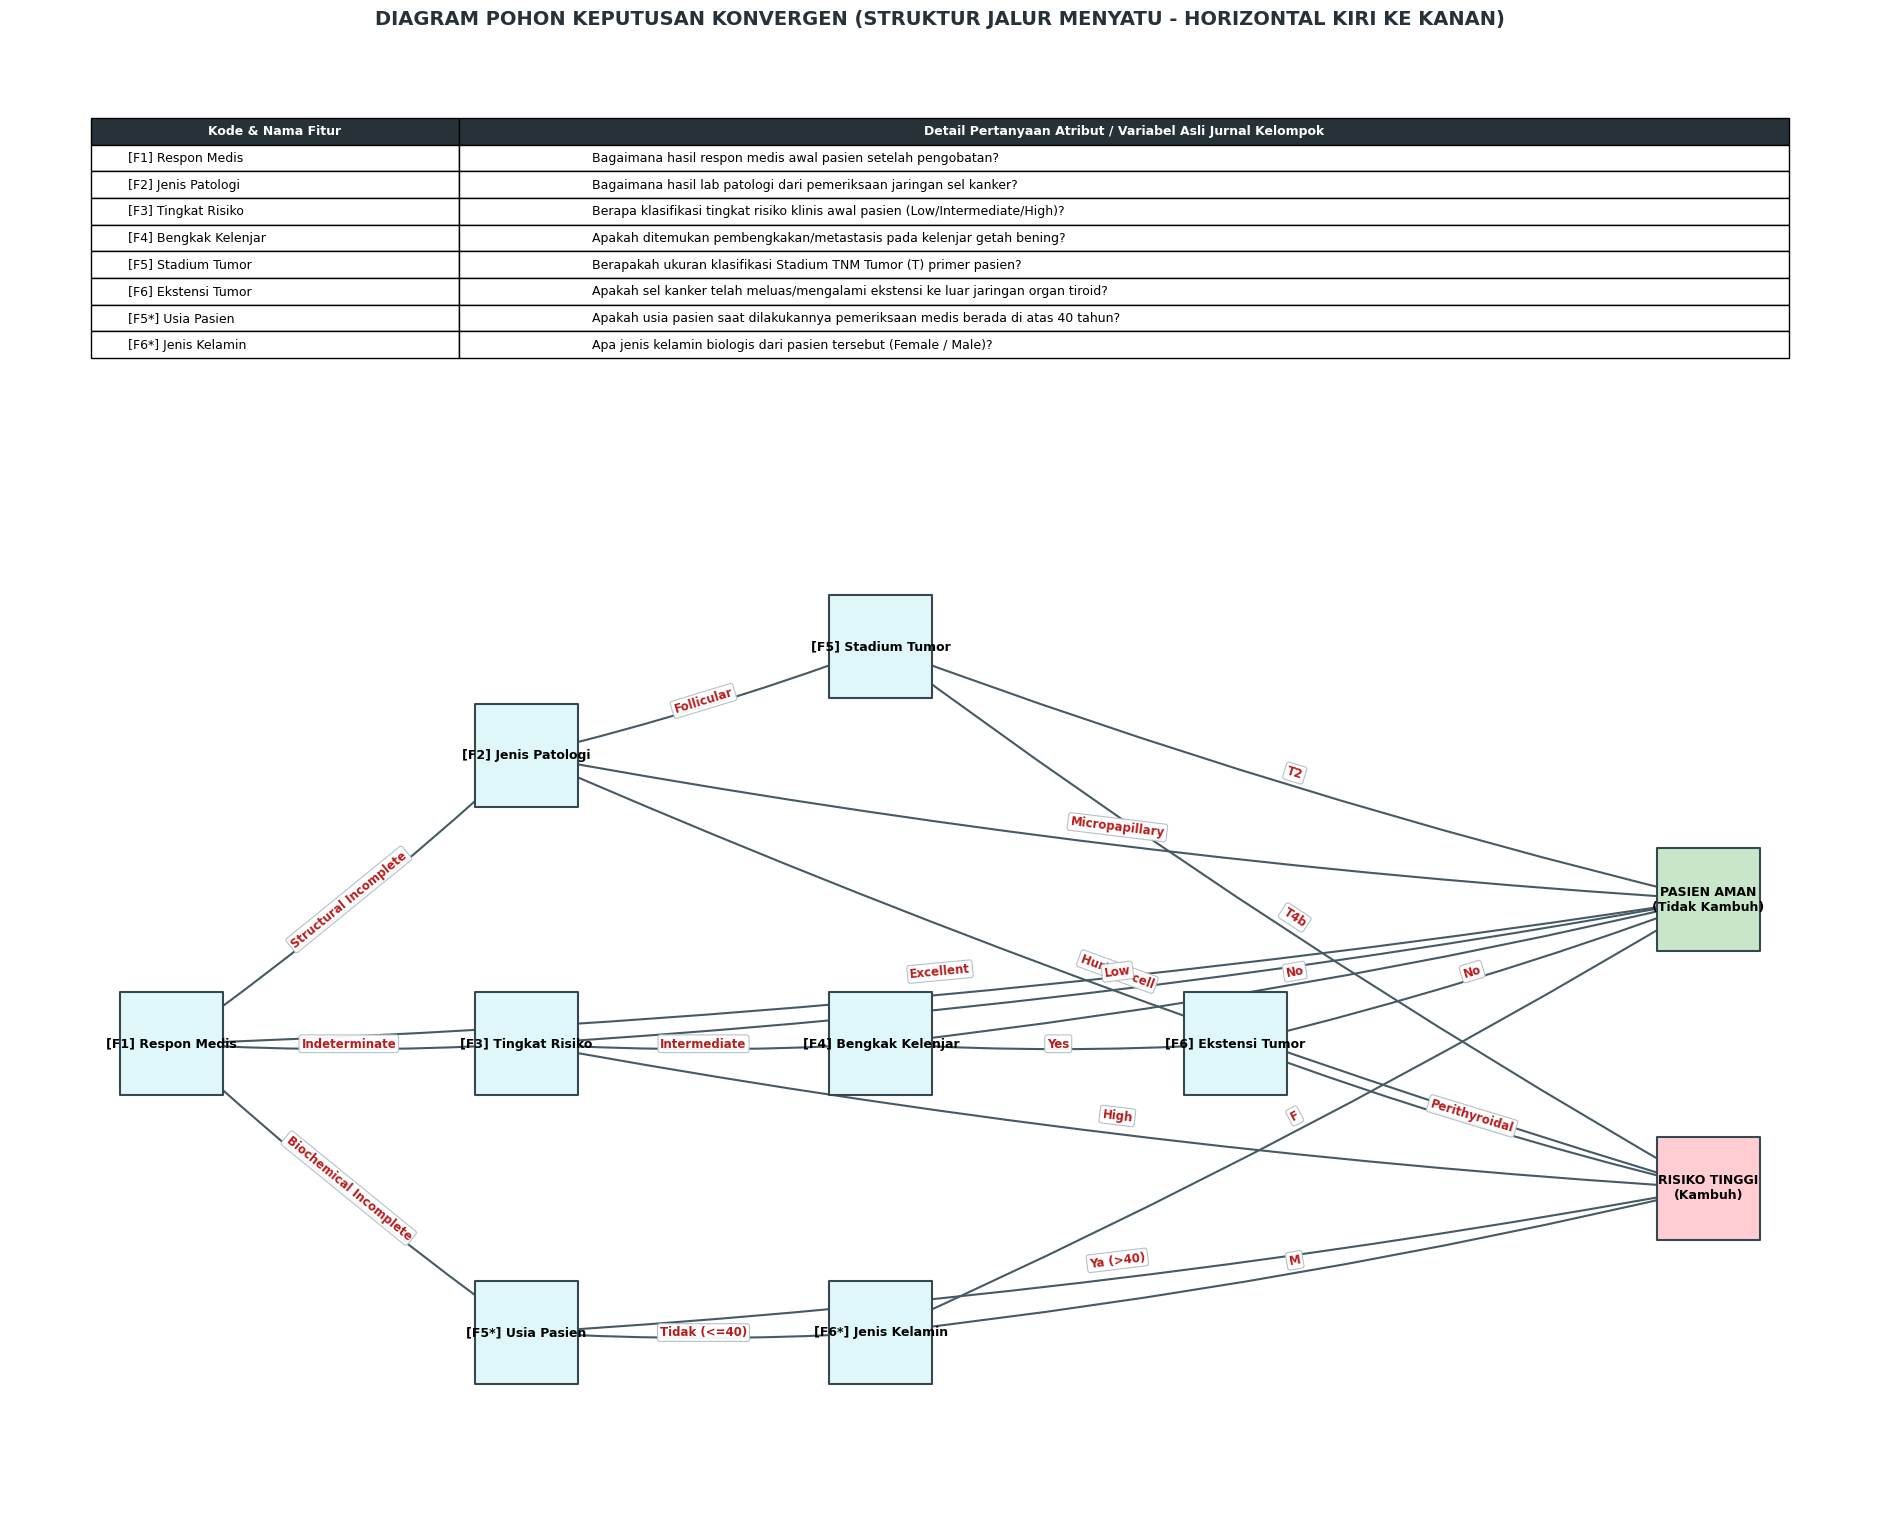

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. STRUKTUR DATA NODE POHON KEPUTUSAN (Materi Utama SDA)
# Membuat blueprint node pembentuk komponen pohon keputusan
class Node:
    def __init__(self, konten_atau_hasil, nama_atribut=None, kode_fitur=None):
        # Menyimpan teks pertanyaan fitur ataupun teks kesimpulan akhir di daun
        self.konten = konten_atau_hasil.strip()  # Bersihkan spasi liar di ujung teks
        # Menyimpan string nama kolom target yang dicari di dataset CSV pasien
        self.nama_atribut = nama_atribut
        # Menyimpan kode indeks pengenal fitur biar dokumentasi rapi (misal: F1)
        self.kode_fitur = kode_fitur
        # Wadah dictionary untuk menampung rute cabang anak berdasarkan pilihan jawaban
        self.cabang = {}

    def tambah_cabang(self, pilihan_jawaban, node_anak):
        # Mendaftarkan pilihan jawaban sebagai key dan node tujuan sebagai valuenya
        self.cabang[pilihan_jawaban] = node_anak

# 2. MEMBANGUN POHON KEPUTUSAN MANUAL (6 FITUR DENGAN KODE SINGKAT)
def buat_pohon_tiroid_6_fitur():
    # Membuat objek daun hasil akhir aman tunggal agar semua panah aman bisa menyatu
    daun_aman = Node("PASIEN AMAN\n(Tidak Kambuh)")
    # Membuat objek daun hasil akhir bahaya tunggal agar semua panah kambuh bisa menyatu
    daun_bahaya = Node("RISIKO TINGGI\n(Kambuh)")

    # Membuat node pertanyaan stadium tumor primer (F5) dengan merujuk ke kolom 'T'
    node_tumor = Node("[F5] Stadium Tumor", nama_atribut="T", kode_fitur="F5")
    # Mendaftarkan seluruh variasi stadium tumor yang berkategori aman ke daun_aman
    node_tumor.tambah_cabang("T1a", daun_aman)
    node_tumor.tambah_cabang("T1b", daun_aman)
    node_tumor.tambah_cabang("T2", daun_aman)
    # Mendaftarkan seluruh variasi stadium tumor yang tergolong ganas ke daun_bahaya
    node_tumor.tambah_cabang("T3a", daun_bahaya)
    node_tumor.tambah_cabang("T3b", daun_bahaya)
    node_tumor.tambah_cabang("T4a", daun_bahaya)
    node_tumor.tambah_cabang("T4b", daun_bahaya)

    # Membuat node pertanyaan ekstensi tumor (F6) dengan merujuk ke kolom 'Extension'
    node_ekstensi = Node("[F6] Ekstensi Tumor", nama_atribut="Extension", kode_fitur="F6")
    # Jika tidak ada perluasan (No), maka alur diarahkan langsung ke daun_aman
    node_ekstensi.tambah_cabang("No", daun_aman)
    # Jika ada perluasan keluar tiroid, alur dipetakan langsung ke daun_bahaya
    node_ekstensi.tambah_cabang("Minimal", daun_bahaya)
    node_ekstensi.tambah_cabang("Gross", daun_bahaya)
    node_ekstensi.tambah_cabang("Perithyroidal", daun_bahaya)

    # Membuat gerbang utama pohon (Akar) berupa pertanyaan respon medis (F1)
    root = Node("[F1] Respon Medis", nama_atribut="Response", kode_fitur="F1")
    # Jika respon pengobatan awal adalah Excellent, dipastikan kondisi pasien aman
    root.tambah_cabang("Excellent", daun_aman)

    # Membuat node pertanyaan rumpun lab patologi (F2) berdasarkan kolom 'Pathology'
    node_patologi = Node("[F2] Jenis Patologi", nama_atribut="Pathology", kode_fitur="F2")
    # Menentukan nasib rute kategori Micropapillary langsung bermuara ke aman
    node_patologi.tambah_cabang("Micropapillary", daun_aman)
    # Menentukan nasib rute kategori Hurthle cell langsung bermuara ke bahaya
    node_patologi.tambah_cabang("Hurthle cell", daun_bahaya)
    # Rute Papillary dan Follicular diwajibkan cek kondisi stadium tumor dulu
    node_patologi.tambah_cabang("Papillary", node_tumor)
    node_patologi.tambah_cabang("Follicular", node_tumor)
    # Menyambungkan keseluruhan rumpun patologi ini ke cabang Structural Incomplete
    root.tambah_cabang("Structural Incomplete", node_patologi)

    # Membuat node pertanyaan tingkat risiko klinis (F3) merujuk ke kolom 'Risk'
    node_risiko = Node("[F3] Tingkat Risiko", nama_atribut="Risk", kode_fitur="F3")
    # Klasifikasi Low otomatis dipetakan aman dan High otomatis dipetakan bahaya
    node_risiko.tambah_cabang("Low", daun_aman)
    node_risiko.tambah_cabang("High", daun_bahaya)

    # Membuat node pertanyaan bengkak kelenjar (F4) merujuk ke kolom 'Adenopathy'
    node_kelenjar = Node("[F4] Bengkak Kelenjar", nama_atribut="Adenopathy", kode_fitur="F4")
    # Jika tidak bengkak (No) maka aman, jika bengkak (Yes) lempar ke cek ekstensi tumor
    node_kelenjar.tambah_cabang("No", daun_aman)
    node_kelenjar.tambah_cabang("Yes", node_ekstensi)

    # Hubungkan rumpun kelenjar getah bening ke opsi risiko tingkat Intermediate
    node_risiko.tambah_cabang("Intermediate", node_kelenjar)
    # Hubungkan sub-pohon tingkat risiko ke cabang utama akar Indeterminate
    root.tambah_cabang("Indeterminate", node_risiko)

    # Membuat node penanda pertanyaan usia pasien (F5*) berpatokan pada kolom 'Age'
    node_umur = Node("[F5*] Usia Pasien", nama_atribut="Age", kode_fitur="F5*")
    # Membuat node penanda pertanyaan jenis kelamin (F6*) berpatokan pada kolom 'Gender'
    node_gender = Node("[F6*] Jenis Kelamin", nama_atribut="Gender", kode_fitur="F6*")
    # Wanita (F) dipetakan ke daun aman sedangkan pria (M) dipetakan ke daun bahaya
    node_gender.tambah_cabang("F", daun_aman)
    node_gender.tambah_cabang("M", daun_bahaya)
    # Hubungkan node umur sebagai anak langsung dari cabang Biochemical Incomplete
    root.tambah_cabang("Biochemical Incomplete", node_umur)

    # Kembalikan node akar beserta pointer gender & daun bahaya untuk penelusuran graf
    return root, node_gender, daun_bahaya


# 3. STRATEGI REKURSIF STRUKTUR MENYATU (DIRECTED ACYCLIC GRAPH)
def bangun_grafik_menyatu(node, G, node_gender, daun_bahaya, parent_id=None, label_panah=""):
    # Hentikan fungsi rekursif jika penelusuran menyentuh node kosong
    if node is None:
        return

    # KUNCI UTAMA: Cek jika node adalah daun akhir sejati tanpa anak/tanpa kolom atribut
    if not node.cabang and node.nama_atribut is None:
        # Gunakan string konten murni sebagai ID unik agar seluruh panah melebur kesini
        node_id = node.konten.strip()
    else:
        # Kombinasikan nama node dengan nama parent agar nama pertanyaan tidak tabrakan di graf
        node_id = node.konten.strip() if parent_id is None else f"{node.konten.strip()} (via {parent_id.split('(')[0].strip()})"

    # Masukkan entitas node baru beserta label tampilannya ke dalam objek graf G
    G.add_node(node_id, label=node.konten.strip())

    # Jika pemanggil memiliki parent, hubungkan relasi panah dari parent ke anak saat ini
    if parent_id:
        G.add_edge(parent_id, node_id, title=label_panah)

    # Intervensi algoritma khusus jika penelusuran sampai pada fitur umur ('Age')
    if node.nama_atribut == "Age":
        # Ambil string konten asli dari daun bahaya untuk dijadikan target ID langsung
        id_daun_bahaya = daun_bahaya.konten.strip()
        # Daftarkan simpul daun bahaya ke dalam graf agar siap ditarik garis panah
        G.add_node(id_daun_bahaya, label=daun_bahaya.konten.strip())
        # Tarik garis lurus bypass dari node umur ke daun bahaya untuk pilihan Ya (>40)
        G.add_edge(node_id, id_daun_bahaya, title="Ya (>40)")

        # Alihkan sisa rute Tidak (<=40) secara rekursif untuk lanjut mendaki ke node gender
        bangun_grafik_menyatu(node_gender, G, node_gender, daun_bahaya, node_id, "Tidak (<=40)")
        # Selesaikan eksekusi agar tidak terjadi perulangan ganda pada cabang umur
        return

    # Telusuri seluruh cabang anak yang dimiliki node ini menggunakan perulangan
    for pilihan, anak_node in node.cabang.items():
        # Panggil kembali fungsi diri sendiri untuk memproses anak di level berikutnya
        bangun_grafik_menyatu(anak_node, G, node_gender, daun_bahaya, node_id, pilihan)


def tampilkan_grafik_menyatu_horizontal(root_node, node_gender, daun_bahaya):
    # Buat objek penampung struktur graf berarah menggunakan pustaka NetworkX
    G = nx.DiGraph()
    # Panggil fungsi rekursif untuk mengisi relasi antar node di dalam graf G
    bangun_grafik_menyatu(root_node, G, node_gender, daun_bahaya)

    # KOORDINAT MANUAL (LAYERED LEFT-TO-RIGHT) untuk menyusun tata letak horizontal
    pos = {
        # Posisi tiang awal: Menaruh root di titik pangkal koordinat kiri
        "[F1] Respon Medis": (0, 0),

        # Posisi tiang kedua: Sebaran cabang tingkat pertama hasil saringan root
        "[F2] Jenis Patologi (via [F1] Respon Medis)": (3, 4),
        "[F3] Tingkat Risiko (via [F1] Respon Medis)": (3, 0),
        "[F5*] Usia Pasien (via [F1] Respon Medis)": (3, -4),

        # Posisi tiang ketiga: Sebaran fitur kedalaman level kedua
        "[F5] Stadium Tumor (via [F2] Jenis Patologi)": (6, 5.5),
        "[F4] Bengkak Kelenjar (via [F3] Tingkat Risiko)": (6, 0),
        "[F6*] Jenis Kelamin (via [F5*] Usia Pasien)": (6, -4),

        # Posisi tiang keempat: Menyusun letak fitur ekstensi di kolom kanan tengah
        "[F6] Ekstensi Tumor (via [F4] Bengkak Kelenjar)": (9, 0),

        # Posisi tiang kelima: Muara akhir tempat berkumpulnya semua jawaban pasien
        "PASIEN AMAN\n(Tidak Kambuh)": (13, 2),
        "RISIKO TINGGI\n(Kambuh)": (13, -2)
    }

    # Menyiapkan kanvas gambar berukuran ekstra besar agar tidak saling bertumpukan
    plt.figure(figsize=(24, 15))

    # Proses seleksi warna kotak berdasarkan kata kunci status konten nodenya
    node_colors = []
    for n in G.nodes():
        if "AMAN" in n:
            node_colors.append('#c8e6c9')  # Warna hijau pastel penanda kondisi aman
        elif "RISIKO" in n:
            node_colors.append('#ffcdd2')  # Warna merah pastel penanda kondisi bahaya
        else:
            node_colors.append('#e0f7fa')  # Warna biru muda untuk kotak pertanyaan biasa

    # Ambil kamus teks label asli yang melekat pada tiap node graf
    labels = nx.get_node_attributes(G, 'label')

    # Gambarkan seluruh simpul node berbentuk kotak sesuai warna dan koordinat manual pos
    nx.draw_networkx_nodes(G, pos, node_size=5500, node_color=node_colors, node_shape='s', edgecolors='#37474f', linewidths=1.5)
    # Cetak teks isi pertanyaan di tengah-tengah kotak dengan tipe huruf tebal
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', font_family='sans-serif')

    # Hubungkan garis panah antar simpul dengan lengkungan tipis rad=0.03 agar jalur paralel rapi
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=22, edge_color='#455a64', width=1.5, connectionstyle="arc3,rad=0.03")

    # Ambil teks pilihan jawaban yang menjadi jembatan antar panah penunjuk
    edge_labels = nx.get_edge_attributes(G, 'title')
    # Tempelkan label teks pilihan jawaban di atas garis panah dengan latar balon putih
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels,
        font_size=8.5, font_color='#b71c1c', font_weight='bold',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#b0bec5", lw=0.8, alpha=0.95)
    )

    # Menyusun data teks informasi pelengkap untuk dijadikan tabel legenda resmi
    data_legenda = [
        ["[F1] Respon Medis", "Bagaimana hasil respon medis awal pasien setelah pengobatan?"],
        ["[F2] Jenis Patologi", "Bagaimana hasil lab patologi dari pemeriksaan jaringan sel kanker?"],
        ["[F3] Tingkat Risiko", "Berapa klasifikasi tingkat risiko klinis awal pasien (Low/Intermediate/High)?"],
        ["[F4] Bengkak Kelenjar", "Apakah ditemukan pembengkakan/metastasis pada kelenjar getah bening?"],
        ["[F5] Stadium Tumor", "Berapakah ukuran klasifikasi Stadium TNM Tumor (T) primer pasien?"],
        ["[F6] Ekstensi Tumor", "Apakah sel kanker telah meluas/mengalami ekstensi ke luar jaringan organ tiroid?"],
        ["[F5*] Usia Pasien", "Apakah usia pasien saat dilakukannya pemeriksaan medis berada di atas 40 tahun?"],
        ["[F6*] Jenis Kelamin", "Apa jenis kelamin biologis dari pasien tersebut (Female / Male)?"]
    ]

    # Membuat objek tabel informasi dan menaruh posisinya melayang di atas kanvas gambar
    tabel_legenda = plt.table(
        cellText=data_legenda,
        colLabels=["Kode & Nama Fitur", "Detail Pertanyaan Atribut / Variabel Asli Jurnal Kelompok"],
        colWidths=[0.18, 0.65],
        loc="top",
        cellLoc="left"
    )
    # Matikan konfigurasi ukuran font otomatis bawaan matplotlib
    tabel_legenda.auto_set_font_size(False)
    # Tetapkan ukuran teks di dalam sel tabel legenda sebesar 9 pt
    tabel_legenda.set_fontsize(9)
    # Setel kerenggangan dimensi lebar dan tinggi baris tabel legenda
    tabel_legenda.scale(1.1, 1.6)

    # Berikan aksen warna gelap pada baris judul kolom (header) tabel legenda
    for (row, col), cell in tabel_legenda.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white') # Teks judul tebal warna putih
            cell.set_facecolor('#263238')                     # Latar belakang biru dongker gelap

    # Berikan ruang kosong ekstra (padding atas) agar visual grafik tidak menabrak tabel legenda
    ax = plt.gca()
    ax.set_ylim(-6.5, 9.5)  # Menaikkan batas plafon Y ke posisi 9.5 sebagai pembatas longgar

    # Tulis judul diagram di paling atas tengah dengan pad penjarak yang longgar
    plt.title("DIAGRAM POHON KEPUTUSAN KONVERGEN (STRUKTUR JALUR MENYATU - HORIZONTAL KIRI KE KANAN)", fontsize=14, fontweight='bold', pad=240, color='#263238')
    # Hilangkan visualisasi garis penggaris sumbu X dan Y agar diagram bersih total
    plt.axis('off')

    # Simpan hasil render gambar ke dalam berkas eksternal beresolusi tajam (300 DPI)
    plt.savefig("pohon_6_fitur_menyatu_legenda_atas.png", dpi=300, bbox_inches='tight')
    # Cetak konfirmasi sukses pembuatan grafik di konsol python
    print("[SUKSES]: Grafik model konvergen horizontal + legenda posisi atas berhasil dibuat!")
    # Tampilkan jendela gambar grafik pohon ke layar monitor pengguna
    plt.show()

# 4. PENELUSURAN ALUR DATA INDIVIDU (LOGIKA TERMINAL KODE KELOMPOK)
def telusuri_alur_6_fitur(node, data_pasien, node_gender, daun_bahaya):
    # Validasi jika perjalanan telah mendarat di node daun paling ujung pohon
    if not node.cabang:
        # Tampilkan kesimpulan akhir dengan meluruskan teks enter (\n) menjadi sebaris
        print(f" -> [{node.konten.replace('\n', ' ')}]")
        # Selesai dan keluar dari fungsi penelusuran baris pasien saat ini
        return

    # Penanganan logika bersyarat khusus apabila mendeteksi kolom umur ('Age')
    if node.nama_atribut == "Age":
        # Konversi data umur bertipe string di tabel menjadi integer utuh
        umur = int(data_pasien["Age"])
        # Jika umur di atas 40 tahun, langsung bypass ke arah daun bahaya
        if umur > 40:
            print(f" -> [{node.konten}](Ya, {umur} thn)", end="")
            print(f" -> [{daun_bahaya.konten.replace('\n', ' ')}]")
            return
        # Jika umur <= 40 tahun, belokkan rute menuju pemeriksaan jenis kelamin (gender)
        else:
            print(f" -> [{node.konten}](Tidak, {umur} thn)", end="")
            telusuri_alur_6_fitur(node_gender, data_pasien, node_gender, daun_bahaya)
            return

    # Ambil nama identitas kolom target berdasarkan konfigurasi internal node
    atribut = node.nama_atribut
    # Cari nilai teks jawaban riil milik si pasien di dalam tabel database
    jawaban = str(data_pasien[atribut])
    # Tampilkan status langkah penelusuran saat ini beserta data klinis si pasien
    print(f" -> [{node.konten}]({jawaban})", end="")

    # Periksa kesediaan kunci jawaban pasien di dalam daftar opsi cabang node anak
    if jawaban in node.cabang:
        # Melompat maju ke node anak secara rekursif berdasarkan jawaban terpilih
        telusuri_alur_6_fitur(node.cabang[jawaban], data_pasien, node_gender, daun_bahaya)
    else:
        # Tampilkan teks penutup jika alur terputus di tengah jalan karena ketidakcocokan data
        print(" -> [Selesai]")


# 5. EKSEKUSI PROGRAM UTAMA
try:
    # Mengimpor file dataset rekam medis tiroid ke dalam bentuk DataFrame Pandas
    df = pd.read_csv('Thyroid_Diff.csv')
    # Bangun cetakan struktur pohon 6 fitur dan simpan referensi variabel kuncinya
    pohon_saya, node_gender, daun_bahaya = buat_pohon_tiroid_6_fitur()

    # Menggabungkan 5 data pasien teratas dan 5 data pasien terbawah
    # .head(5) menyaring 5 sampel awal, .tail(5) menyaring 5 sampel akhir untuk variasi data
    df_simulasi_6f = pd.concat([df.head(5), df.tail(5)])

    print("SIMULASI PENELUSURAN DATA KASUS PASIEN (5 AWAL & 5 AKHIR) - MODEL 6 FITUR:")
    # Melakukan perulangan langsung pada baris-baris data gabungan menggunakan iterrows
    for indeks, baris_pasien in df_simulasi_6f.iterrows():
        # Menampilkan penanda nomor indeks baris asli pasien dari file Excel/CSV
        print(f"\nPASIEN pada Baris Index #{indeks}")
        # Jalankan mesin penelusur rute keputusan untuk mengecek status kesehatan pasien saat ini
        telusuri_alur_6_fitur(pohon_saya, baris_pasien, node_gender, daun_bahaya)

    print("\n[INFO]: Membuka pop-up grafik berorientasi menyatu horizontal...")
    # Luncurkan fungsi visualisasi utama untuk melukis diagram pohon di layar monitor
    tampilkan_grafik_menyatu_horizontal(pohon_saya, node_gender, daun_bahaya)

except FileNotFoundError:
    # Pesan pengingat pencegah program macet jika letak file CSV terlupa dipindahkan
    print("File CSV 'Thyroid_Diff.csv' tidak ditemukan. Pastikan file berada di folder yang sama.")